In [1]:
from functools import partial
from typing import Union

import os

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['JAX_PLATFORMS']='cpu'

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from tqdm import tqdm

import sys
import pickle

# Construct the relative path to the precond_gd directory
relative_path = os.path.join('..', '..')  # Go up two levels to reach precond-gd
sys.path.append(os.path.abspath(relative_path))

from precond_gd.utils.cg import conjugate_gradient
from precond_gd.data.data_utils import batch_data
from precond_gd.utils.jacobian_tools import flatten_jacobian
from precond_gd.utils.model_utils import create_train_state
from precond_gd.models.MLP import MLP_1D
from precond_gd.utils.plotting import plot_results
from matplotlib import pyplot as plt
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

import optax
from run_exp import PrecondData,train_model


In [2]:
# Create a simple 2D discontinuous function for testing
n = 40
xx = jnp.linspace(0, 1, n)
X, Y = jnp.meshgrid(xx, xx)
x = jnp.vstack((X.flatten(), Y.flatten())).T

# Define a discontinuous function
def discontinuous_function(x):
    # Example: Discontinuous at the line x + y = 0.5
    return jnp.where(x[:, 0] + x[:, 1] < 0.5, 1.0, 0.0)

def complicated_discontinuous_function(x):
    # Define multiple regions with different values
    return jnp.where(
        x[:, 0] + x[:, 1] < 0.5, 1.0,  # Region 1
        jnp.where(
           x[:, 0] + x[:, 1] > 1.5, 2.0,  # Region 2
            jnp.where(
                (x[:, 0] < 0.5) & (x[:, 1] >= 0.5), 0.75,  # Region 3
                0.0
            )
        )
    )

# Apply the function to the input
y = complicated_discontinuous_function(x)
y = y.reshape((-1, 1))

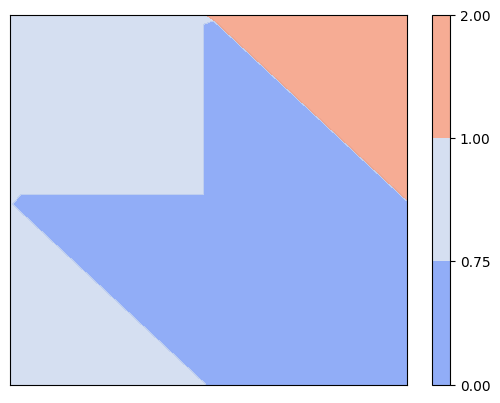

In [3]:
# Plotting
# Y_reshaped = y.reshape(X.shape)
# plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.8)
# plt.colorbar()
# plt.show()

# Assuming X, Y, and y are already defined
Y_reshaped = y.reshape(X.shape)

# Define the specific levels you want to display
levels = [0, 0.74999999, 1, 2]

# Create the contour plot with the specified levels
contour = plt.contourf(X, Y, Y_reshaped, levels=levels, cmap='coolwarm', alpha=0.8)

# Add a colorbar with ticks at the specified levels
cbar = plt.colorbar(contour)
cbar.set_ticks(levels)  # Set colorbar ticks to the specified levels

# Remove axis numbering
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks

# Show the plot
plt.show()

In [4]:
num_runs = 5
force_rerun = False
def save_runs(name, runs):
    filename = f'{name}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(runs, f)

def load_runs(name):
    filename = f'{name}.pkl'
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            runs = pickle.load(f)
        return runs
    else:
        return None

In [5]:
jax.devices()

[CpuDevice(id=0)]

In [6]:
all_sgd_2d_runs = load_runs('sgd-2d')

if (all_sgd_2d_runs is None) or (force_rerun is True):
    model = MLP_1D(num_layers=2,hidden_dim=80)

    for i in range(num_runs):
        state = create_train_state(model, rng=jax.random.key(i), learning_rate=1e-2, 
                           optimizer=optax.sgd(1e-2, 0), shape=jnp.array([1, 1]))
        state, metrics_history_sgd = train_model(state, x, y, num_iterations=1_000_000, obtain_matrices=False, 
                                            lm_schedule=None, batch_size=400, 
                                                 num_track = 1000, 
                                                 seed=i
                                            )
        all_sgd_2d_runs.append((state.params, metrics_history_sgd))
    save_runs('sgd-2d', all_sgd_2d_runs)
else: 
    print('Loaded from save file')


  0%|▏                                                                                                                                        | 1757/1000000 [00:13<2:04:25, 133.72it/s]


KeyboardInterrupt: 

100%|██████████| 200000/200000 [37:52<00:00, 88.00it/s]


In [ ]:
plt.loglog(metrics_history_sgd['train_loss'], label='sgd')
plt.legend()
plt.show()


In [ ]:
len(metrics_history_sgd['train_loss'])

In [ ]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)
state = create_train_state(model, learning_rate=1e-2, 
                   optimizer='sgd', shape=jnp.array([1, 1]))
# state = create_train_state(model, learning_rate=1e-2, 
#                    optimizer=optax.scale_by_backtracking_linesearch(optax.sgd(1e-2, 0)), shape=jnp.array([1, 1]))

state, metrics_history_smw = train_model(state, x, y, num_iterations=1_000_000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=400
                                    )


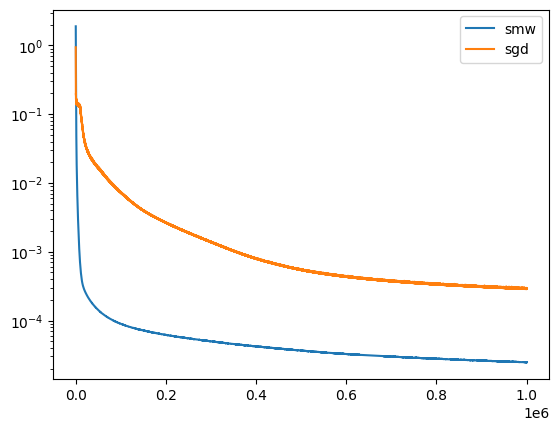

In [64]:
plt.semilogy(metrics_history_smw['train_loss'], label='smw')
plt.semilogy(metrics_history_sgd['train_loss'], label='sgd')
plt.legend()
plt.show()


In [ ]:
# Plotting
plt.contourf(X, Y, metrics_history_smw['prediction'][-1].reshape((40, 40)), levels=50, cmap='coolwarm', alpha=0.8)
# plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.1)

plt.show()

plt.contourf(X, Y, metrics_history_sgd['prediction'][-1].reshape((40, 40)), levels=50, cmap='coolwarm', alpha=0.8)
# plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.1)

plt.show()

In [ ]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='gn-exact',
)
state = create_train_state(model, learning_rate=1e-2, 
                   optimizer='sgd', shape=jnp.array([1, 1]))
# state = create_train_state(model, learning_rate=1e-2, 
#                    optimizer=optax.scale_by_backtracking_linesearch(optax.sgd(1e-2, 0)), 
#                            shape=jnp.array([1, 1])
#                 )


state, metrics_history_gn = train_model(state, x, y, num_iterations=50000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=400
                                    )


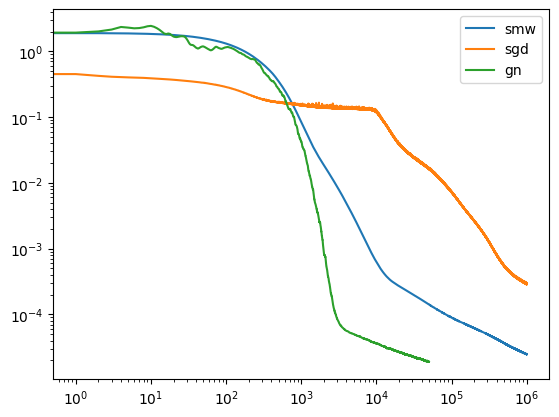

In [27]:
plt.loglog(metrics_history_smw['train_loss'], label='smw')
plt.loglog(metrics_history_sgd['train_loss'], label='sgd')
plt.loglog(metrics_history_gn['train_loss'], label='gn')
plt.legend()
plt.show()


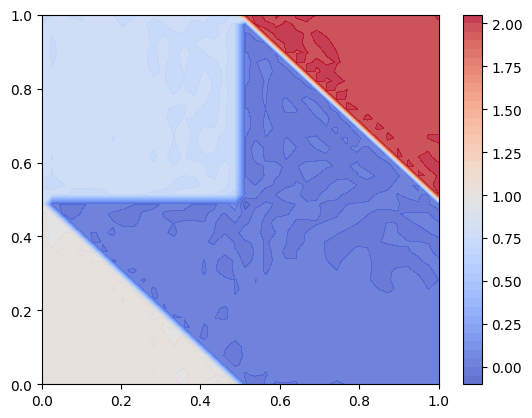

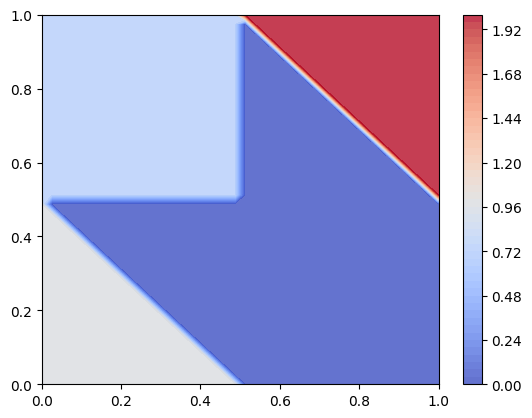

In [47]:
Y_reshaped = y.reshape(X.shape)
plt.contourf(X, Y, metrics_history_gn['prediction'][-1].reshape(X.shape), levels=50, cmap='coolwarm', alpha=0.8)
plt.colorbar()
plt.show()
plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.8)
plt.colorbar()
plt.show()


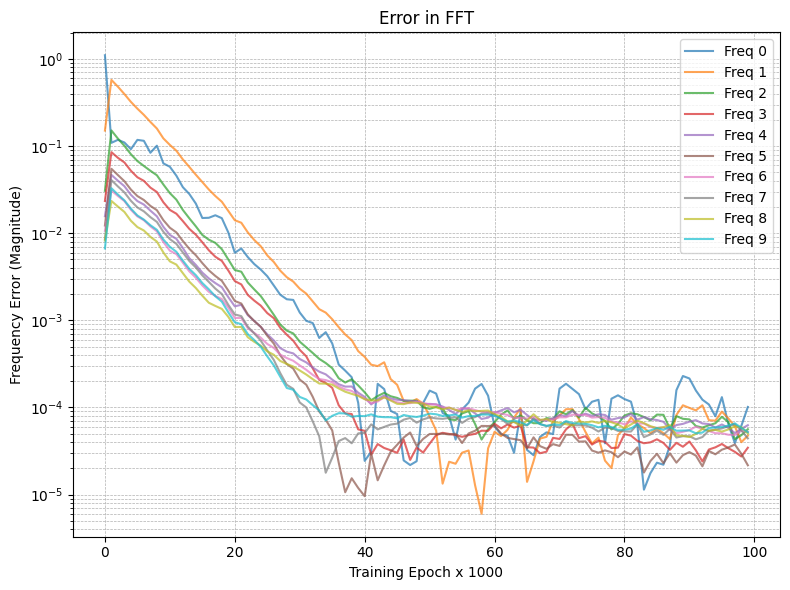

In [72]:

# Assuming y and metrics_history_gn['prediction'] are 2D arrays
n, m = Y_reshaped.shape  # Get the dimensions of the 2D array
all_fft = []

for est in metrics_history_gn['prediction']:
    # Compute the 2D FFT of the residual
    fft_err = jnp.fft.fft2(Y_reshaped - est.reshape(X.shape)) / (n * m)
    # Take the magnitude of the FFT and keep only the first quadrant
    fft_err = jnp.abs(fft_err[:n // 2, :m // 2])
    all_fft.append(fft_err.flatten())
    
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i][0:100], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 1000')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

100%|█████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1470.15it/s]


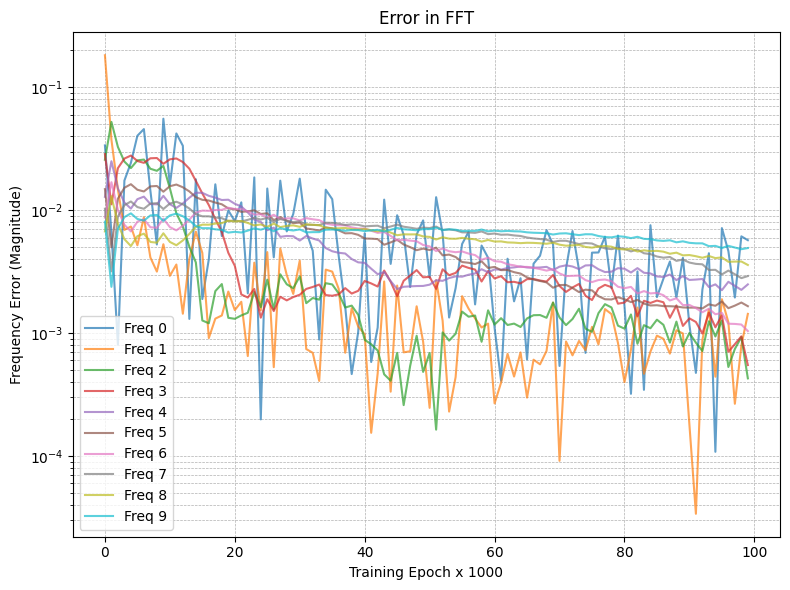

In [73]:

# Assuming y and metrics_history_gn['prediction'] are 2D arrays
n, m = Y_reshaped.shape  # Get the dimensions of the 2D array
all_fft = []

for est in tqdm(metrics_history_sgd['prediction']):
    # Compute the 2D FFT of the residual
    fft_err = jnp.fft.fft2(Y_reshaped - est.reshape(X.shape)) / (n * m)
    # Take the magnitude of the FFT and keep only the first quadrant
    fft_err = jnp.abs(fft_err[:n // 2, :m // 2])
    all_fft.append(fft_err.flatten())
    
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i][0:100], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 1000')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

100%|███████████████████████████████████████████████| 10000/10000 [00:06<00:00, 1495.16it/s]


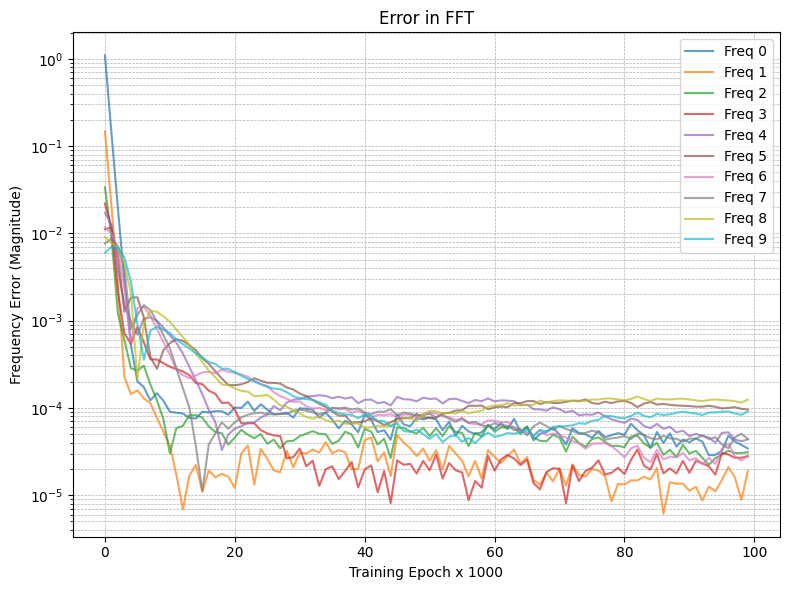

In [75]:

# Assuming y and metrics_history_gn['prediction'] are 2D arrays
n, m = Y_reshaped.shape  # Get the dimensions of the 2D array
all_fft = []

for est in tqdm(metrics_history_smw['prediction']):
    # Compute the 2D FFT of the residual
    fft_err = jnp.fft.fft2(Y_reshaped - est.reshape(X.shape)) / (n * m)
    # Take the magnitude of the FFT and keep only the first quadrant
    fft_err = jnp.abs(fft_err[:n // 2, :m // 2])
    all_fft.append(fft_err.flatten())
    
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    plt.semilogy(all_fft[i][0:1000:10], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

plt.title('Error in FFT')
plt.xlabel('Training Epoch x 1000')
plt.ylabel('Frequency Error (Magnitude)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [76]:
print(len(metrics_history_sgd['prediction']))
print(len(metrics_history_smw['prediction']))
print(len(metrics_history_gn['prediction']))

1000
10000
500


# Plot the things together; just GN and SGD for best visualization 

100%|█████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1469.09it/s]


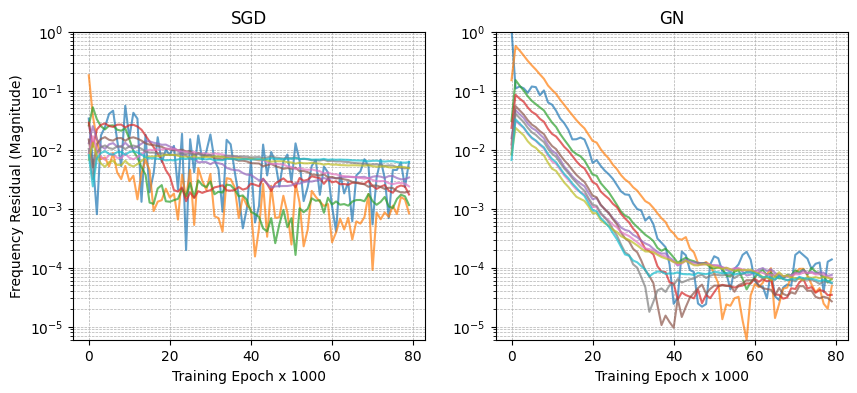

<Figure size 800x600 with 0 Axes>

In [87]:
# Create subfigures
# fig, subfigs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 4 columns
fig, subfigs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 4 columns


# Assuming y and metrics_history_gn['prediction'] are 2D arrays
n, m = Y_reshaped.shape  # Get the dimensions of the 2D array
all_fft = []

for est in metrics_history_gn['prediction']:
    # Compute the 2D FFT of the residual
    fft_err = jnp.fft.fft2(Y_reshaped - est.reshape(X.shape)) / (n * m)
    # Take the magnitude of the FFT and keep only the first quadrant
    fft_err = jnp.abs(fft_err[:n // 2, :m // 2])
    all_fft.append(fft_err.flatten())
    
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

for i in range(num_frequencies_to_plot):
    subfigs[1].semilogy(all_fft[i][0:80], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

subfigs[1].set_title('GN')
subfigs[1].set_xlabel('Training Epoch x 1000')
# subfigs[1].set_ylabel('Frequency Error (Magnitude)')
subfigs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[1].set_ylim(6e-6, 1)


# Assuming y and metrics_history_gn['prediction'] are 2D arrays
n, m = Y_reshaped.shape  # Get the dimensions of the 2D array
all_fft = []

for est in tqdm(metrics_history_sgd['prediction']):
    # Compute the 2D FFT of the residual
    fft_err = jnp.fft.fft2(Y_reshaped - est.reshape(X.shape)) / (n * m)
    # Take the magnitude of the FFT and keep only the first quadrant
    fft_err = jnp.abs(fft_err[:n // 2, :m // 2])
    all_fft.append(fft_err.flatten())
    
all_fft = jnp.array(all_fft).T

# Limit the number of frequencies to plot
num_frequencies_to_plot = min(all_fft.shape[0], 10)  # Adjust as needed

plt.figure(figsize=(8, 6))
for i in range(num_frequencies_to_plot):
    subfigs[0].semilogy(all_fft[i][0:80], label=f'Freq {i}', alpha=0.7)  # Use alpha for transparency

subfigs[0].set_title('SGD')
subfigs[0].set_xlabel('Training Epoch x 1000')
subfigs[0].set_ylabel('Frequency Residual (Magnitude)')
subfigs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[0].set_ylim(6e-6, 1)
plt.tight_layout()
plt.show()